In [1]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


In [3]:
!pip install joblib

Defaulting to user installation because normal site-packages is not writeable


In [4]:
!pip install numpy pandas scikit-learn xgboost matplotlib seaborn joblib

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('loan_ml_ready_dataset.csv')
print("Loaded!", df.shape)

Loaded! (1345310, 201)


In [6]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split (X,y, test_size=0.2, random_state=42, stratify=y)

print("traning set size", X_train.shape)
print("testing set size", X_test.shape)
print("class balancing in traing set:")
print(y_train.value_counts())

traning set size (1076248, 200)
testing set size (269062, 200)
class balancing in traing set:
loan_status
0    861401
1    214847
Name: count, dtype: int64


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling Done")

Scaling Done


In [8]:
lr_model = LogisticRegression(class_weight='balanced',max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
print("LR Model Trained")

LR Model Trained


In [9]:
from sklearn.metrics import classification_report, roc_auc_score
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_lr, target_names=['Repaid','Deafult']))
print("ROC-AOC Score:", roc_auc_score(y_test,y_prob_lr))

              precision    recall  f1-score   support

      Repaid       0.89      0.64      0.75    215350
     Deafult       0.32      0.68      0.44     53712

    accuracy                           0.65    269062
   macro avg       0.61      0.66      0.59    269062
weighted avg       0.78      0.65      0.68    269062

ROC-AOC Score: 0.7208026079324836


In [10]:
X_train.columns = X_train.columns.str.replace('[', '', regex=False)
X_train.columns = X_train.columns.str.replace(']', '', regex=False)
X_train.columns = X_train.columns.str.replace('<', '', regex=False)

X_test.columns = X_test.columns.str.replace('[', '', regex=False)
X_test.columns = X_test.columns.str.replace(']', '', regex=False)
X_test.columns = X_test.columns.str.replace('<', '', regex=False)

print("Column names cleaned")
print("Sample columns:", X_train.columns.tolist()[:5])

Column names cleaned
Sample columns: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment']


In [11]:
xgb_model = XGBClassifier(scale_pos_weight=4, n_estimators=200, max_depth=4, random_state=42)
xgb_model.fit(X_train, y_train)
print("XGBoost Trained")

XGBoost Trained


In [12]:
y_pred_xgb= xgb_model.predict(X_test)
y_prob_xgb= xgb_model.predict_proba(X_test)[:,1]

print("XGBoost results")
print(classification_report(y_test, y_pred_xgb, target_names=['Repaid', 'Defaulted']))
print("ROC-AUC Score", roc_auc_score(y_test, y_prob_xgb))

XGBoost results
              precision    recall  f1-score   support

      Repaid       0.89      0.66      0.76    215350
   Defaulted       0.33      0.68      0.45     53712

    accuracy                           0.67    269062
   macro avg       0.61      0.67      0.60    269062
weighted avg       0.78      0.67      0.70    269062

ROC-AUC Score 0.7348571212708783


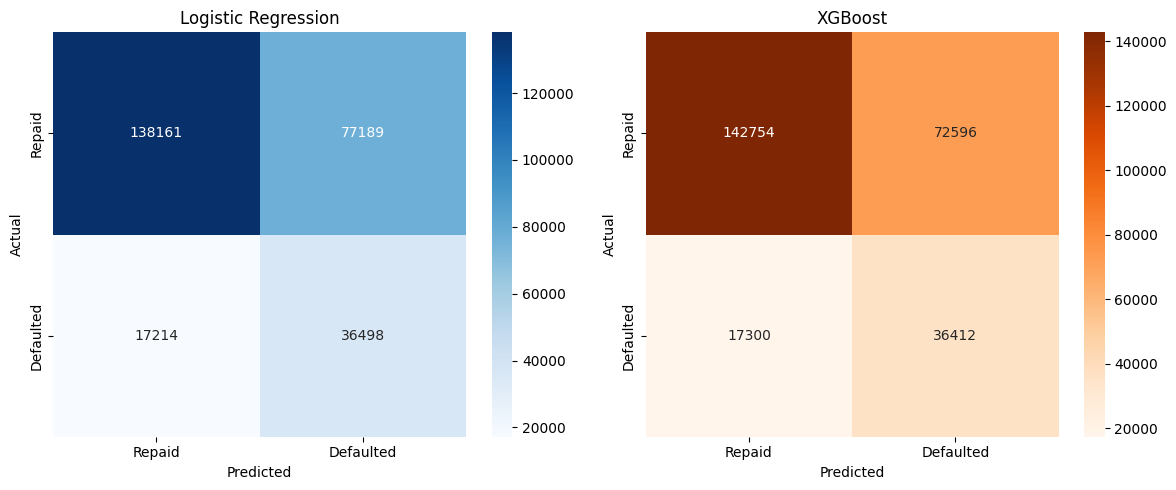

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Repaid', 'Defaulted'],
            yticklabels=['Repaid', 'Defaulted'])
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [14]:
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('model saved')

model saved
